In [27]:
import os
os.environ['OMP_NUM_THREADS'] = '1'

import sys
import re
import json
import cv2
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
import sklearn
from sklearn.metrics import classification_report, confusion_matrix
from scipy import signal
import ddddocr
import torch
from torchvision.models import resnet18, ResNet18_Weights
from copy import copy
import pyautogui
from datetime import datetime
import time
from tqdm import tqdm
from torch import nn
import torch.nn.functional as F
import math

---
# 准备数据集开始训练

In [2]:
# 收集必要的数据
try:
    print("开始截图... 按 Ctrl+C 停止")
    while True:
        timestamp = datetime.now().strftime("%Y%m%d_%H%M%S_%f")[:-3]  # 毫秒级时间戳
        file_path = os.path.join("source", "screenshot", f"screenshot_{timestamp}.png")
        screenshot = pyautogui.screenshot()
        screenshot.save(file_path)
        time.sleep(0.5)
except KeyboardInterrupt:
    print("\n程序已停止")

开始截图... 按 Ctrl+C 停止

程序已停止


In [3]:
# 全局配置
class NanokaDetector():
    def __init__(self, image):
        super(NanokaDetector, self).__init__()

        self.image = image
        self.gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
        self.ocr = ddddocr.DdddOcr(show_ad=False)
        self.size_info = []

    def update_image(self, image):
        '''
        更新使用的图片, 我们可以直接调取这个图片进行分析
        '''
        self.image = image
        self.gray = cv2.cvtColor(self.image, cv2.COLOR_BGR2GRAY)
                         
    # 亮点综合检测器
    def threhold_detector(self, plot=False, show=False):
        '''
        利用检测点的圆形高亮特性确定目标点
        '''
        # 一顿操作最后只剩下需要的信息
        _, binary_image = cv2.threshold(self.gray, 155, 255, cv2.THRESH_BINARY)
        blured_image = cv2.blur(binary_image, (9,9))
        median_image = cv2.medianBlur(blured_image, 7)
        _, rebinary_image = cv2.threshold(median_image, 155, 255, cv2.THRESH_BINARY)
        
        # 掩膜
        height, width = self.gray.shape
        border_ratio = 0.1
        mask = np.zeros_like(self.gray, dtype=np.uint8)
        border_x = int(width * border_ratio)
        border_y = int(height * border_ratio)
        inner_width = width - 2 * border_x
        inner_height = height - 2 * border_y
        cv2.rectangle(mask, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, -1)
        masked_rebinary_image = cv2.bitwise_and(mask, rebinary_image, mask=mask)
        
        # 提取大范围亮色特征 (轮廓分析)
        targets, anti_targets = [], []
        origin_image = None
        if plot:
            origin_image = self.image.copy()
            # 绘制掩膜
            cv2.rectangle(origin_image, (border_x, border_y), (border_x + inner_width, border_y + inner_height), 255, 2)
    
        # 抓住所有需要的点特征
        contours, _ = cv2.findContours(masked_rebinary_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in contours:
            x, y, w, h = cv2.boundingRect(contour)
            center_x, center_y = x + w // 2, y + h // 2
            targets.append((center_x, center_y, w, h))
            
            if plot:
                cv2.rectangle(origin_image, (x, y), (x+w, y+h), (0, 255, 0), 2)  # 绿色矩形
                cv2.circle(origin_image, (center_x, center_y), 5, (255, 0, 0), -1)  # 红色点

        # 消除不需要的点特征
        masked_median_image = cv2.medianBlur(cv2.medianBlur(masked_rebinary_image, 11), 11)
        acontours, _ = cv2.findContours(masked_median_image, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
        for contour in acontours:
            x, y, w, h = cv2.boundingRect(contour)
            center_x, center_y = x + w // 2, y + h // 2
            anti_targets.append((center_x, center_y, w, h))
            
            if plot:
                cv2.rectangle(origin_image, (x-5, y-5), (x+w+5, y+h+5), (255, 0, 0), 2)  # 红色矩形
    
        if show:
            fig, axes = plt.subplots(1, 1, figsize=(10, 6))
            axes.imshow(origin_image)
            axes.set_title("Analyzed Image")
            plt.show()
        
        return np.array(targets, dtype=np.float32), np.array(anti_targets, dtype=np.float32), origin_image

    def ocr_detector(self, border_ratio=0.1):
        '''
        ddddocr 图像文字识别
        '''
        height, width = self.gray.shape
        mask = np.zeros_like(self.gray, dtype=np.uint8)
        border_x = int(width * border_ratio)
        border_y = int(height * border_ratio)
        
        text_area = self.gray[height-border_y:, :border_x]    
        _, encoded_img = cv2.imencode('.png', text_area)
        img_bytes = encoded_img.tobytes()
    
        # 只能检测编码字节流
        result = self.ocr.classification(img_bytes)
        return result

    def re_keyword_detector(self, texts):
        """
        ASCII字符清洗检测子串, 子串是提前规定好的
        """
        patterns = [r'添[\x00-\x7F]{0,3}加[\x00-\x7F]{0,3}好[\x00-\x7F]{0,3}友', r'好[\x00-\x7F]{0,3}友', r'挚[\x00-\x7F]{0,3}友']
        dataframes = {
            '识别文本': [],
            '星盘页': [],
            '添加好友': [],
            '好友': [],
            '挚友': [],
        }
    
        for text in texts:
            matchs = list([bool(re.search(pattern, text)) for pattern in patterns])
            dataframes['星盘页'].append(True in matchs)
            dataframes['添加好友'].append(matchs[0] == True)
            dataframes['好友'].append(matchs[1] == True)
            dataframes['挚友'].append(matchs[2] == True)
            dataframes['识别文本'].append(text)
            
        return pd.DataFrame(dataframes)

    def image_spiltor(self):
        '''
        用于将数据切分成我们想要的形式之后进行分类任务就可以了
        '''
        targets, anti_targets, plot_image = self.threhold_detector(plot=False, show=False)

        pre, post = None, None
        if len(targets) != 0 and len(anti_targets) != 0:
            diff = np.expand_dims(targets[:,:2], axis=1) - np.expand_dims(anti_targets[:,:2], axis=0)
            distance = np.sqrt(np.sum(diff*diff, axis=2))
            point = np.where(distance < 15)[0]
            post = copy(targets[point])
            pre = [i for i in targets.tolist() if i not in post]
        elif len(targets) != 0 and len(anti_targets) == 0:
            pre = copy(targets)
            post = []
        elif len(targets) == 0:
            pre = []
            post = []

        # 不同的类别进行不同的切割方式, pre 是需要进一步处理的内容, post是确定的很大的不需要处理的内容
        pre_scaler, post_scaler, pre_sub_gray, post_sub_gray = 5, 2, [], []
        if len(pre) != 0:
            pre_sub_gray = [self.gray[int(y-max(w,h)*pre_scaler):int(y+max(w, h)*pre_scaler), int(x-max(w, h)*pre_scaler):int(x+max(w, h)*pre_scaler)] for x, y, w, h in pre]
        if len(post) != 0:
            post_sub_gray = [self.gray[int(y-max(w,h)*post_scaler):int(y+max(w, h)*post_scaler), int(x-max(w, h)*post_scaler):int(x+max(w, h)*post_scaler)] for x, y, w, h in post]
        return pre_sub_gray, post_sub_gray
        
    def multi_detector(self, border_ratio=0.1, plot=False, show=False):
        '''
        多重鉴别器, 用于检测是否在星盘页并且判断类型
        '''
        text = self.ocr_detector()
        pf = self.re_keyword_detector([text])
    
        if not bool(pf['星盘页'].values[0]):
            # print("不在星盘页, 不进行后续检测")
            if show:
                fig, axes = plt.subplots(1, 1, figsize=(15, 5))
                axes.imshow(self.image)
                axes.set_title("Useless Image")
                axes.axis('off')
                plt.show()
            return {"code":-1, "info":"不在星盘页"}, None
    
        if bool(pf['添加好友'].values[0]):
            # print("当前页面为添加好友页")
            if show:
                fig, axes = plt.subplots(1, 1, figsize=(15, 5))
                axes.imshow(self.image)
                axes.set_title("Make Friends Image")
                axes.axis('off')
                plt.show()
            return {"code":1, "info":"本页面为添加好友页"}, None
    
        if bool(pf['好友'].values[0]) or bool(pf['挚友'].values[0]):
            # print("检测为有效的星盘页")
            pre_sub_gray, post_sub_gray = self.image_spiltor()
            return {"code":0, "info":"识别成功", "pre":pre_sub_gray, "post":post_sub_gray}, None
        return {"code":-2, "info":"无法预知的错误!"}, None

In [4]:
FOLDER_PATH = "screenshot"
for filename in os.listdir(os.path.join("source", FOLDER_PATH)):
    if filename.endswith(".png") or filename.endswith(".jpg"):
        # print(f"\nProcessing {filename}...")

        detector = NanokaDetector(image=cv2.imread(os.path.join("source", FOLDER_PATH, filename)))
        info, _ = detector.multi_detector()

        if info["code"] != 0:
            continue
        
        pre, post = info["pre"], info["post"]
        for i, file in enumerate(pre):
            file = cv2.resize(file, (224, 224))
            cv2.imwrite(os.path.join("source", "datasets", "nanoka_v1", "{}_pre_{}.jpg".format(filename.split(".")[0], i)), file)
        for i, file in enumerate(post):
            file = cv2.resize(file, (224, 224))
            cv2.imwrite(os.path.join("source", "datasets", "nanoka_v1", "{}_post_{}.jpg".format(filename.split(".")[0], len(pre)+i)), file)
    else:
        print(f"Skipping {filename}, not an image file.")
print("Done")

Done


In [20]:
# 重新制作数据集
class HeartDataset(torch.utils.data.Dataset):
    def __init__(self, path=os.path.join("source","datasets","nanoka_v1")):
        super(HeartDataset, self).__init__()

        self.root_dir = path
        self.cls = os.listdir(self.root_dir)
        self.images = []
        self.labels = []

        for cls in self.cls:
            paths = os.listdir(os.path.join(self.root_dir, cls))
            for path in paths:
                self.images.append(os.path.join(self.root_dir, cls, path))
                self.labels.append(int(cls))
        
    def __getitem__(self, idx): # X 形状为 (B=idx, T, F)
        return torch.tensor(cv2.imread(self.images[idx], cv2.IMREAD_GRAYSCALE), dtype=torch.float32), torch.tensor(self.labels[idx], dtype=torch.long)
        
    def __len__(self):
        if len(self.labels) != len(self.images):
            raise RuntimeError("长度错误: len(self.labels) != len(self.images)")
        return len(self.labels)

train 16: 100%|███████████████████████████████████████████████| 60/60 [00:02<00:00, 21.40it/s, loss=0.000709]


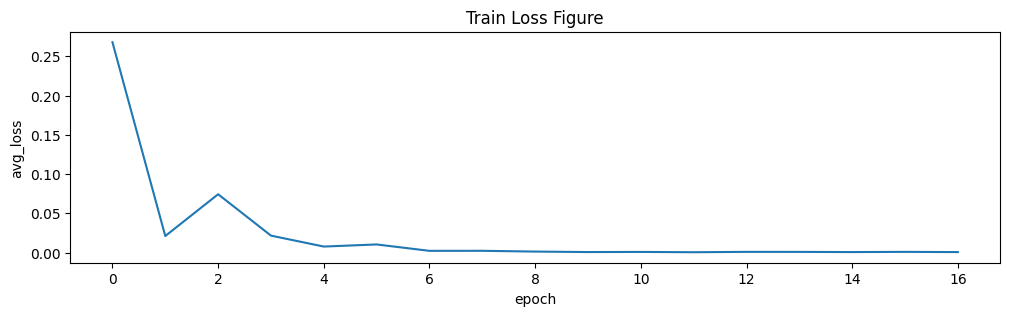

valid 0: 100%|███████████████████████████████████████████████████████████████| 60/60 [00:01<00:00, 57.37it/s]

[[150   0   0   0]
 [  0 150   0   0]
 [  0   0 150   0]
 [  0   0   0 150]]

              precision    recall  f1-score   support

           0       1.00      1.00      1.00       150
           1       1.00      1.00      1.00       150
           2       1.00      1.00      1.00       150
           3       1.00      1.00      1.00       150

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600



In [28]:
# 训练模型
model = resnet18(weights=ResNet18_Weights.IMAGENET1K_V1)
# 需要对 ResNet 进行适配
model.conv1 = nn.Conv2d(1, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
model.fc = nn.Linear(in_features=512, out_features=4, bias=True)
model = model.to("cuda:0") # 使用 CUDA 加速训练

MODEL_FOLDER = "models"

# 为什么要写这个是因为多线程 dataloader 需要这个
if __name__ == "__main__":
    episode = 20
    train_dataset = HeartDataset(path=os.path.join("source","datasets","nanoka_v1"))
    train_dataloader = torch.utils.data.DataLoader(train_dataset, batch_size=10, shuffle=True, num_workers=0)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(model.parameters(), lr=2e-5)

    max_early_stopping, early_stopping = 5, 0
    best_loss = math.inf # 最小化损失所以初始化最大
    batch_losses = []
    
    try:
        for epoch in range(episode):
            optimizer.zero_grad()
            losses = []
            with tqdm(train_dataloader, desc="train {}".format(epoch)) as tbar:
                for i , (feature, label) in enumerate(tbar):
                    feature = feature.to("cuda:0")
                    label = label.to("cuda:0")
                    
                    output = model(feature.unsqueeze(1))
                    loss = criterion(output, label)
        
                    loss.backward()
                    optimizer.step()
    
                    losses.append(loss.cpu().item())
                    tbar.set_postfix(loss=np.average(losses))
            
            batch_avg_loss = np.average(losses)
            batch_losses.append(batch_avg_loss)
            
            if batch_avg_loss < best_loss:
                early_stopping = 0
                best_loss = batch_avg_loss
                torch.save(model.state_dict(), os.path.join(MODEL_FOLDER, "resnet18_model_best.pth"))
            else:
                early_stopping += 1
                if early_stopping >= max_early_stopping:
                    raise Exception("达到 EarlyStopping 基准, 训练提前停止")
    except Exception as e:
        if str(e) !=  "达到 EarlyStopping 基准, 训练提前停止":
            print("捕获到异常:", e)
    finally:
        torch.save(model.state_dict(), os.path.join(MODEL_FOLDER, "resnet18_model_last.pth"))
        plt.figure(figsize=(12,3))
        plt.plot(batch_losses)
        plt.title("Train Loss Figure")
        plt.xlabel("epoch")
        plt.ylabel("avg_loss")
        plt.show()

        pred, y = [], []
        with tqdm(train_dataloader, desc="valid 0".format(epoch)) as tbar:
            for i , (feature, label) in enumerate(tbar):
                feature = feature.to("cuda:0")
                y.extend(label.detach().numpy())
                
                output = model(feature.unsqueeze(1))
                p = torch.argmax(output, dim=1).detach().cpu().numpy()
                pred.extend(p)
        
        cm = confusion_matrix(y, pred)
        print("{}".format(cm))
        report = classification_report(y, pred)
        print("\n{}".format(report))